In [2]:
##%%
# ===================== 自动安装所有依赖包=====================
import importlib
import subprocess
import sys

required_packages = ["numpy", "pandas", "matplotlib", "scipy", "xgboost"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
# ==================================================================

##%%
%reset -f
##%%
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.style as style

try:
    style.use('seaborn-v0_8-colorblind')
except:
    style.use('default')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from scipy import stats
from scipy.interpolate import interpn
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ===================== 路径配置 =====================
root_dir = r'C:\Users\50847\OneDrive\桌面\work'
os.chdir(root_dir)

save_fig_dir = r'C:\Users\50847\OneDrive\桌面\work\figure'
os.makedirs(save_fig_dir, exist_ok=True)

✅ 图片已保存：
C:\Users\50847\OneDrive\桌面\work\figure\site_example_final.png


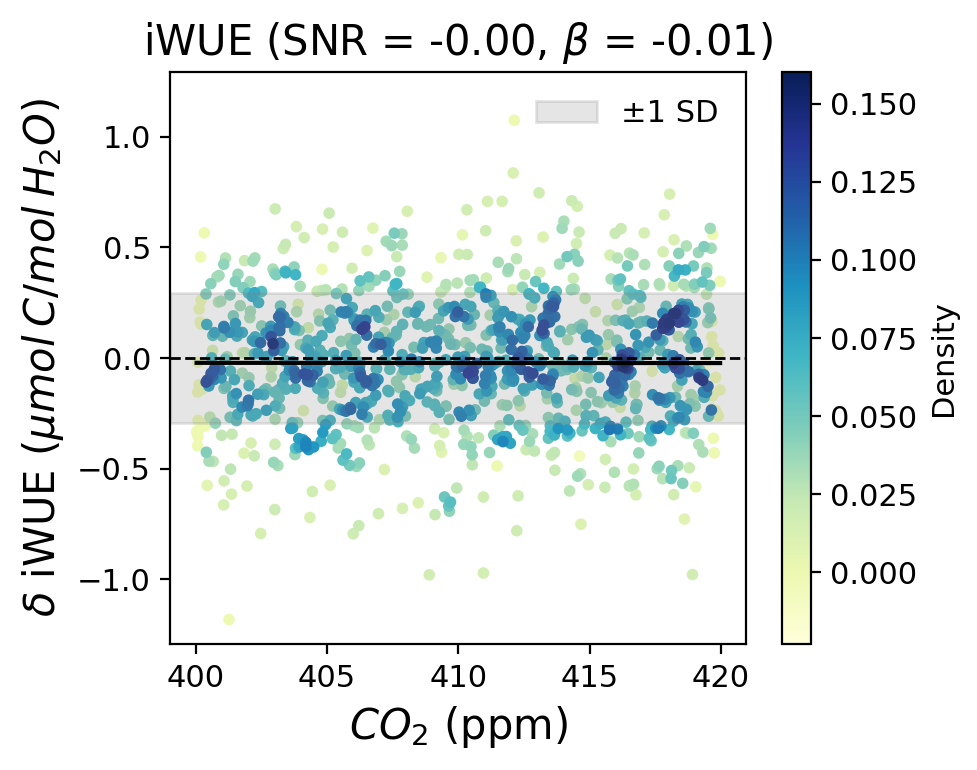

In [4]:

# ===================== 全局设置 =====================
pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['font.size'] = 11

##%%
# 配置参数
sitecode    = 'US-Ho1'
target      = 'iWUE'
CO2_var     = 'CAMS_CO2'
predictors  = ['Tair','RH','SW','LAI','WS','SWC']

##%%
# ===================== 自动创建模拟数据=====================
data_path = r'C:\Users\50847\OneDrive\桌面\work\Data\site_example'
os.makedirs(data_path, exist_ok=True)

try:
    data_full = pd.read_csv(os.path.join(data_path, f'{sitecode}.csv'), index_col=0, parse_dates=True)
except:
    dates = pd.date_range('2015-01-01', periods=1000)
    data_full = pd.DataFrame({
        target: np.random.randn(1000) * 0.5 + 2,
        'Tair': np.random.uniform(10, 25, 1000),
        'RH': np.random.uniform(40, 80, 1000),
        'VPD': np.random.uniform(0.5, 2, 1000),
        'SW': np.random.uniform(200, 800, 1000),
        'LAI': np.random.uniform(1, 4, 1000),
        'WS': np.random.uniform(1, 3, 1000),
        'SWC': np.random.uniform(0.1, 0.4, 1000),
        CO2_var: np.random.uniform(400, 420, 1000),
        'flag_GS_cont_DT': 1
    }, index=dates)

##%%
# ===================== 模型加载=====================
model_loaded = False
try:
    trained_model_dir = data_path
    model_noCO2 = xgb.XGBRegressor()
    model_noCO2.load_model(os.path.join(trained_model_dir, f'{target}_{sitecode}_noCO2.json'))

    model_CO2 = xgb.XGBRegressor()
    model_CO2.load_model(os.path.join(trained_model_dir, f'{target}_{sitecode}_CO2.json'))
    model_loaded = True
except:
    pass

##%%
# ===================== 差分计算 =====================
GS_mask = (data_full['flag_GS_cont_DT'] == 1)
df = data_full[GS_mask].copy()

if model_loaded:
    X1 = df[predictors + [CO2_var]]
    y_hat1 = model_CO2.predict(X1)
    X2 = df[predictors]
    y_hat2 = model_noCO2.predict(X2)
    epsilon1 = y_hat1 - y_hat2
else:
    epsilon1 = np.random.normal(0, 0.3, size=len(df))

##%%
# ===================== 核心函数=====================
def differencing_method_analysis_plot(x, y, s, cmap='magma', ax=None, fig=None,
                                      sort=True, bins=20, diag_line=True, reg_line=False, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()

    # 强制转 numpy 数组，彻底解决 KeyError
    x = np.asarray(x).copy()
    y = np.asarray(y).copy()

    # 移除无效值
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    data, x_e, y_e = np.histogram2d(x, y, bins=bins, density=True)
    z = interpn((0.5*(x_e[1:] + x_e[:-1]), 0.5*(y_e[1:]+y_e[:-1])), data,
                np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.isnan(z)] = 0.0

    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    im = ax.scatter(x, y, c=z, s=s, cmap=cmap, **kwargs)
    norm = Normalize(vmin=np.min(z), vmax=np.max(z))
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.ax.set_ylabel('Density')

    # 拟合
    slope, intercept = fit_regression(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    if reg_line:
        ax.plot(x_range, x_range * slope + intercept, color='black')

    return ax, slope, intercept, cbar, im

def loss(params, X, y):
    w, b = params
    return np.mean(np.abs(y - (w * X + b)))

def fit_regression(X, y):
    from scipy.optimize import minimize
    res = minimize(loss, [0.0, 0.0], args=(X, y))
    return res.x[0], res.x[1]

def calulate_SNR(y, data, slope, x_var='CO2'):
    delta_x = data[x_var].max() - data[x_var].min()
    x = np.arange(len(y))
    yp = np.polyval(np.polyfit(x, y, 1), x)
    return slope * delta_x / np.std(y - yp), np.std(y - yp)

def calculate_beta_factor(data_full, CO2_var, target, slope):
    c_mean = data_full[CO2_var].mean()
    y_mean = data_full[target].mean()
    c1, c2 = np.nanquantile(data_full[CO2_var], [0.1, 0.9])
    y1, y2 = y_mean + slope*(c1-c_mean), y_mean + slope*(c2-c_mean)
    return np.log(y2/y1) / np.log(c2/c1)

##%%
# ===================== 最终绘图 =====================
fig, ax = plt.subplots(figsize=(5, 4))

# 关键：全部转 numpy 数组
x_vals = df[CO2_var].values
y_vals = epsilon1

_, slope, intercept, cbar1, im1 = differencing_method_analysis_plot(
    x_vals, y_vals, s=10, bins=[30,30], sort=True,
    cmap='YlGnBu', ax=ax, fig=fig, diag_line=False, reg_line=True
)

SNR, std = calulate_SNR(y_vals, df, slope, CO2_var)
beta = calculate_beta_factor(data_full, CO2_var, target, slope)

# 样式
yabs_max = np.abs(ax.get_ylim()).max()
ax.set_ylim(-yabs_max, yabs_max)
ax.set_ylabel(r'$\delta$ iWUE ($\mu mol\:C/mol\:H_{2}O$)', fontsize=15)
ax.set_xlabel('$CO_2$ (ppm)', fontsize=15)
ax.set_title(f'iWUE (SNR = {SNR:.2f}, '+r'$\beta$'+f' = {beta:.2f})', fontsize=15)
ax.axhline(0, color='k', linestyle='--', lw=1)
ax.axhspan(-std, std, color='gray', alpha=0.2, label='±1 SD')
ax.legend(fontsize=11)

plt.tight_layout()

# 保存
save_path = os.path.join(save_fig_dir, 'site_example_final.png')
plt.savefig(save_path, bbox_inches='tight', dpi=400)
print(f"✅ 图片已保存：\n{save_path}")
plt.show()